### **3.3 Exploring Random Walks and Stationarity**

In this practical you will explore the concept of a **random walk**, a foundational idea in time series analysis and financial modelling. The activity is divided into four parts to help you build a strong understanding through simulation and real data analysis.

- **Part 1**: Understanding Stationary vs Non_Stationary Processes.

You will begin by simulating and visualising two time series: one **stationary** and one **non-stationary**.

- **Part 2**: Simulating a Random Walk.

Next, you will simulate a **random walk** in Python - a type of non-stationary process where each value depends on the previous one plus random noise.

- **Part 3**: Predicting a Random Walk.

In this section you will attempt to make naive forecasts of a random walk and evaluate how predictable (or unpredictable) it really is.

- **Part 4**: Analysing Real Data (Google Stock Prices)

Finally, you will load **Alphabet's (Google) historical stock prices** and assess whether the time series behaves like a random walk.

---

This activity will help you:

- Understand the differences between **stationary** and **non-stationary** time series

- Simulate and analyse a **random walk**

- Evaluate the **predictability** of a random walk

- Apply your understanding to a real-world dataset

**Required file:** `GOOGL.csv`

---

This activity has been adapted from [this book](https://www.manning.com/books/time-series-forecasting-in-python-book)

**Preparation: Load the Libraries**

To begin, we will load the libraries required for time series analysis and visualisation. These include:

- `pandas` amd `numpy` for data handling

- `matplotlib` for plotting

- `statsmodels` for time series decomposition, autocorrelation plots, and stationarity testing

We have also included a warning suppression line to keep the output clean, and `%matplotlib inline` to display plots within the norebook.

In [2]:
# Time series tools from the statsmodels library
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf

# Data manipulation
import pandas as pd
import numpy as np

# Plotting library
%matplotlib inline
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

#### **Part 1: Understanding Stationary vs Non-Stationary Processes**

A **stationary process** is one whose key statistical properties - **mean**, **variance**, and **autocorrelation** - remain **constant over time**. Many time series models, such as ARIMA, assume the input data is stationary to produce reliable forecasts.

We can represent a simple time series process using the equation:

$$y_t=C+\alpha_1y_{t-1}+\epsilon_t$$

Where:

- $C$ is a constant
- $\alpha_{1}$ is the **root** of the process
- $\epsilon_{t}$ is random error (white noise)

The **stationarity** of this process depends on the value of $\alpha_{1}$:

- If $\alpha_{1}$ **is between -1 and 1**, the process is **stationary**
- If $\alpha_{1}=1$ (also known as unit root), the process is **non-stationary**

**1.1 Simulating Stationary and Non-Stationary Processes**

To better understand stationarity, we will simulate two different time series:

- One with a **stationary process**, where the autoregressive root $\alpha=0.5$
- One with a **non-stationary process**, where $\alpha=1$, resulting in a unit root

This will allow us to **visualise the difference** between a stationary and a non-stationary series.

In [3]:
# Let's simulate the process of testing stationarity
def simulate_process(is_stationary: bool) -> np.array:
    np.random.seed(42)
    process = np.empty(400)

    # Assuming that the root unit (alpha) is 0.5
    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        # Assuming the root unit (alpha) is 1
        alpha = 1
        process[0] = 10

    for i in range(400):
        if i + 1 < 400:
            process[i + 1] = alpha * process[i] + np.random.normal()
        else:
            break
    return process

In [4]:
# Simulate the stationary and non-stationary
stationary_process = simulate_process(is_stationary=True)
non_stationary_process = simulate_process(is_stationary=False)

The following plot below shows the difference between a **stationary** and a **non-stationary** process:

- The **stationary series** (solid line) fluctuates around a constant mean with a stable variance.
- The **non-stationary series** (dashed line) shows a drifting pattern, with values that wander further from the starting point over time.

This visual comparison helps highlight why testing for stationarity is an important step in time series analysis.

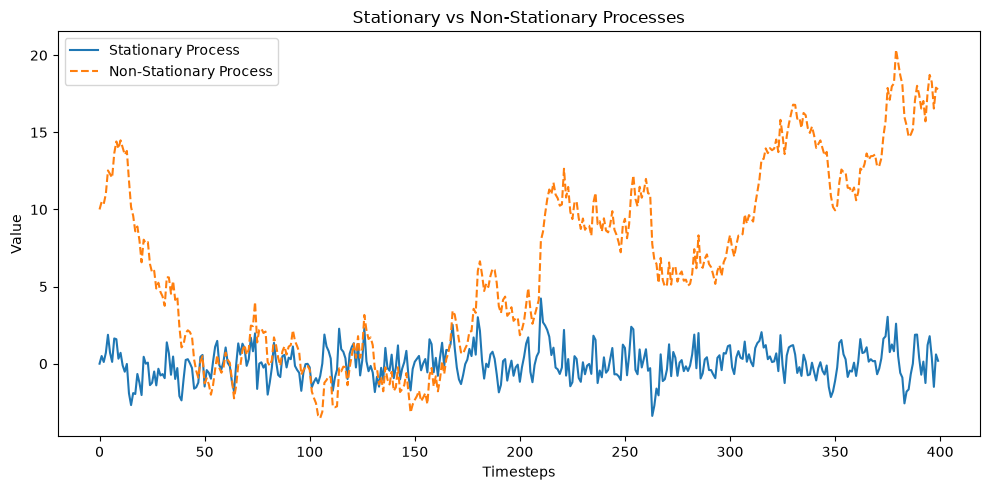

In [5]:
# Plotting the stationary and non-stationary processes
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(stationary_process, linestyle='-', label='Stationary Process')
ax.plot(non_stationary_process, linestyle='--', label='Non-Stationary Process')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Value")
plt.title("Stationary vs Non-Stationary Processes")
plt.tight_layout()
plt.show()

By looking at the two series, you can get an idea of how **stationary** and **non-stationary** processes behave over time.

Notice that the **stationary process** does not show a long-term increase or decrease - it fluctuates around a constant level. This is because **stationary series have constant statistical properties**, such as **mean** and **variance**, that remain stable over time.

In contrast, the **non-stationary process** tends to drift and does not return to a fixed level, indicating that its properties change over time.

**1.2 Mean and Variance of the simulated processes**

The following code can be used for computing the **cumulative mean** at each time point for both processes.

In [6]:
def mean_over_time(process: np.array) -> np.array:
    mean_func = []

    for i in range(1, len(process) + 1):
        mean_func.append(np.mean(process[:i]))

    return np.array(mean_func)

In [7]:
# Compute for stationary mean and non-stationary mean over time
stationary_mean = mean_over_time(stationary_process)
non_stationary_mean = mean_over_time(non_stationary_process)

The plot below shows the **cumulative mean** for the stationary and non-stationary processes.

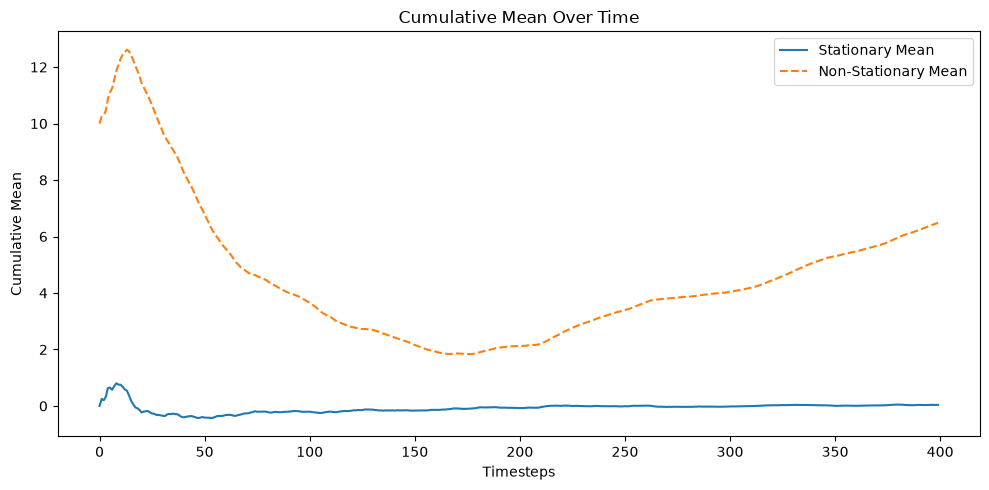

In [8]:
# Plot the cumulative mean over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_mean, linestyle='-', label='Stationary Mean')
ax.plot(non_stationary_mean, linestyle='--', label='Non-Stationary Mean')
ax.legend(loc=1)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Mean")
plt.title("Cumulative Mean Over Time")
plt.tight_layout()
plt.show()

Now we can perform a similar process to track how the **variance** changes over time for each series.

In [9]:
def var_over_time(process: np.array) -> np.array:
    var_func = []

    for i in range(1, len(process) + 1):
        var_func.append(np.var(process[:i]))

    return np.array(var_func)

In [10]:
# Variance over time for both processes
stationary_variance = var_over_time(stationary_process)
non_stationary_variance = var_over_time(non_stationary_process)

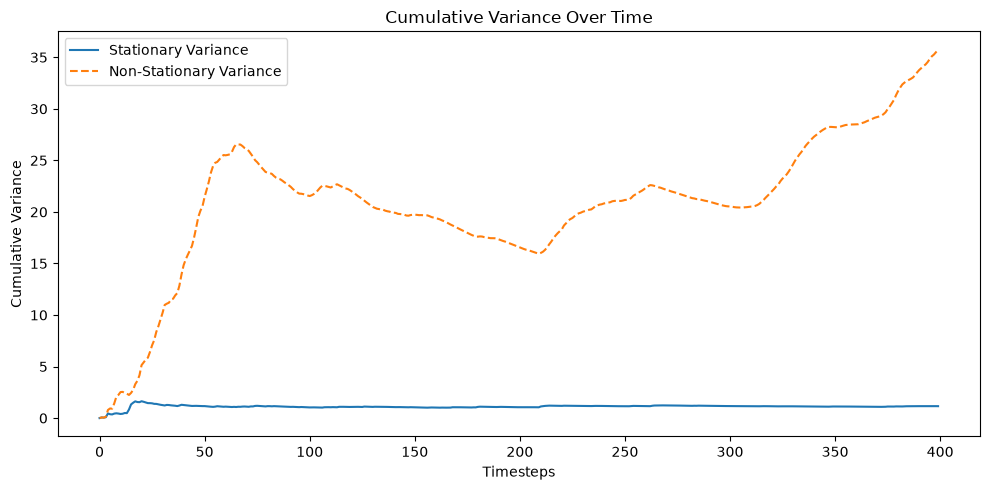

In [11]:
# Plot the cumulative variance over time for both processes
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(stationary_variance, linestyle='-', label='Stationary Variance')
ax.plot(non_stationary_variance, linestyle='--', label='Non-Stationary Variance')
ax.legend(loc=2)
ax.set_xlabel("Timesteps")
ax.set_ylabel("Cumulative Variance")
plt.title("Cumulative Variance Over Time")
plt.tight_layout()
plt.show()

The plot clearly shows the difference between stationary and non-stationary processes.

- In the **stationary** series, both the mean and variance **stabilise quickly and remain relatively constant**.
- In contrast, the **non-stationary** series shows a **drifting mean** and **increasing variance**, which are signs that its statistical properties are changing over time.

**1.3 Testing for stationarity**

Before we can apply most time series forecasting models, we need to verify whether the data is **stationary**.

To do this, we use the **Augmented Dickey-Fuller (ADF) test**, a statistical test designed to detect the presence of a **unit root**.

- **Null hypothesis ($H_{0}$)**: The time series has a **unit root** → it is **non-stationary**
- **Alternative hypothesis ($H_{1}$)**: The time series has **no unit root** → it is **stationary**

If the **p-value** from the test is **less than 0.05**, we can reject the null hypothesis and conclude that the time series is likely stationary.

We will apply the ADF test to both our **simulated stationary** and **non-stationary** series to confirm the differences statistically.

More info: [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.tsa.stattools.adfuller.html)

In [12]:
# Define a function to perform the Augmented Dickey-Fuller test
def run_adf_test(series, label):
    print(f'Augmented Dickey-Fuller Test: {label}')
    result = adfuller(series, autolag='AIC')
    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    out = pd.Series(result[0:4], index=labels)
    
    for key, value in result[4].items():
        out[f'Critical Value ({key})'] = value
    
    print(out.to_string())
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis (reject H0), the series is stationary.")
    else:
        print("Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.")

In [13]:
# Apply the ADF test to both processes
run_adf_test(stationary_process, "Stationary Process")
run_adf_test(non_stationary_process, "Non-Stationary Process")

Augmented Dickey-Fuller Test: Stationary Process
ADF Test Statistic            -1.217185e+01
p-value                        1.414881e-22
#Lags Used                     0.000000e+00
Number of Observations Used    3.990000e+02
Critical Value (1%)           -3.446846e+00
Critical Value (5%)           -2.868811e+00
Critical Value (10%)          -2.570643e+00
Strong evidence against the null hypothesis (reject H0), the series is stationary.
Augmented Dickey-Fuller Test: Non-Stationary Process
ADF Test Statistic              -1.098964
p-value                          0.715485
#Lags Used                       0.000000
Number of Observations Used    399.000000
Critical Value (1%)             -3.446846
Critical Value (5%)             -2.868811
Critical Value (10%)            -2.570643
Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.


#### **Part 2: Simulate a Random Walk**

In this section, we will simulate a basic **random walk** - a time series where each value is the sum of the previous value and a random step. Random walks are often used to model stock prices and other financial data due to their unpredictable, memoryless nature.

**2.1 Steps**

1. **Set a random seed** using `np.random.seed(42)` to ensure reproducibility - the same random numbers will be generated each time the code is run.

2. Generate **1,000 random steps** from a standard normal distribution using `np.random.standard_normal(1000)`.

3. Set the first value of the series to 0.

4. Use `np.cumsum()` to compute the **cumulative sum** of the steps, which forms the random walk.

This process gives us a synthetic time series that we can analyse and compare to real-world financial data later.

In [14]:
# Set the seed for reproducibility
np.random.seed(42)

# Generate 1000 random numbers from a standard normal distribution (mean=0, std=1)
steps = np.random.standard_normal(1000)

# Initialise the first value of the series
steps[0] = 0

# Compute the cumulative sum to simulate a random walk
random_walk = np.cumsum(steps)

**2.2 Visualise the Simulated Random Walk**

Now that we have generated the random walk, we will plot it to observe its behaviour over time.

The plot shows how the series evolves from an initial value of 0 by taking random steps. Even though the changes are random at each step, the overall path can drift significantly - which is a key characteristic of random walks.

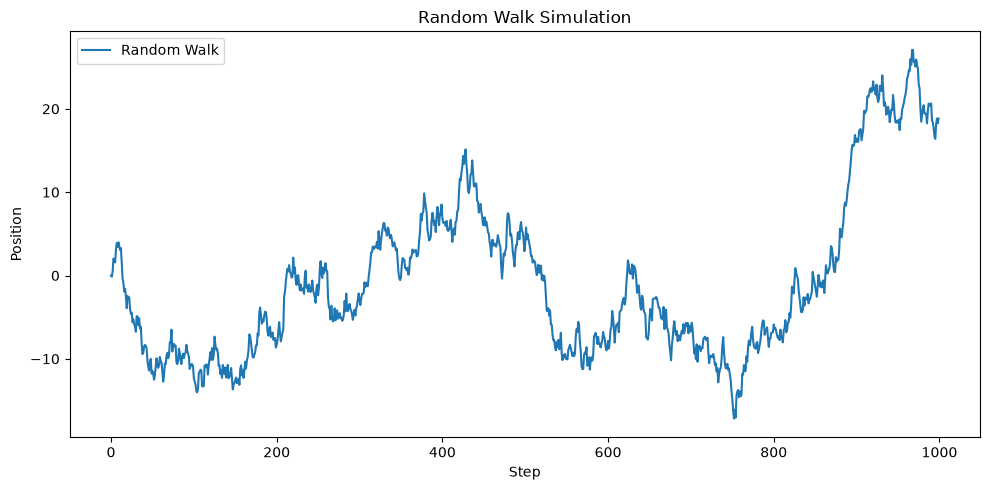

In [15]:
# Plot and visualise the random walk
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(random_walk, linestyle='-', label='Random Walk')
ax.legend(loc=2)
ax.set_title('Random Walk Simulation')
ax.set_xlabel('Step')
ax.set_ylabel('Position')
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig('random_walk_simulation.png', dpi=300)

**2.3 Is our simulation a Random Walk?**

We have generated a new time series that we claim is a **random walk**. In this section, we will verify that claim by checking its key characteristics - specifically, whether it is **non-stationary** and exhibits behaviour consistent with a random walk. We will use the **Augmented Dickey-Fuller (ADF) test** to support our conclusion.

**Note**: A **random walk** is a time series whose **first difference** is **stationary** and **uncorrelated**.

**2.3.1 Check if the series is stationary**

By definition, a random walk is not stationary (but... its first difference is stationary). So first, we test for stationarity on the time series.

In [16]:
run_adf_test(random_walk, "Random Walk Process")

Augmented Dickey-Fuller Test: Random Walk Process
ADF Test Statistic              -0.965952
p-value                          0.765479
#Lags Used                       0.000000
Number of Observations Used    999.000000
Critical Value (1%)             -3.436913
Critical Value (5%)             -2.864437
Critical Value (10%)            -2.568313
Weak evidence against the null hypothesis (fail to reject H0), the series is non-stationary.


Since the p-value is larger than 0.05 we **fail to reject the null hypothesis** of the ADF test (the series has a unit root).

Therefore, the time series is **likely non-stationary**.

**2.3.2 Differentiating the time series**

Since our simulated series shows no seasonal pattern, a first-order difference is appropriate. If the differenced series is stationary, it supports the idea that the original series is a **random walk**.

We use `np.diff()` with `n=1` to compute the difference between consecutive values.

In [18]:
# Apply first-order differencing to the simulated random walk
# This is done to make the series stationary by removing trends and seasonality.
diff_random_walk = np.diff(random_walk, n=1)

After applying first-order differencing to our simulated random walk, we can now visualise the result.

If the differenced series looks like a stable, mean-reverting process with no obvious trend, this supports the idea that the **original series is a random walk** - since a random walk's first difference should be **stationary and uncorrelated**.

The plot below shows the differenced series.

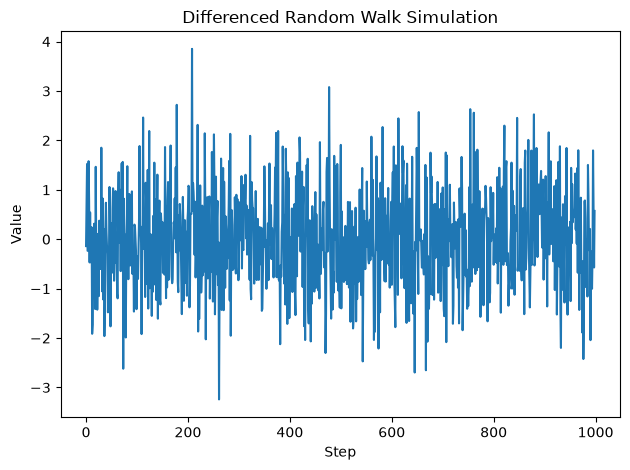

In [20]:
# Visualise the differenced simulated random walk
plt.plot(diff_random_walk, linestyle='-', label='Differenced Random Walk')
plt.title('Differenced Random Walk Simulation')
plt.xlabel('Step')
plt.ylabel('Value')
plt.tight_layout()
plt.show()

**2.3.3 Testing for Stationarity of the First Difference**

If the first-differenced series is **stationaey**, we should see:

- A **low p-value** (typically < 0.05)
- Rejection of the null hypothesis (presence of a unit root)

In [21]:
run_adf_test(diff_random_walk, "Differenced Random Walk Process")

Augmented Dickey-Fuller Test: Differenced Random Walk Process
ADF Test Statistic             -31.789311
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    998.000000
Critical Value (1%)             -3.436919
Critical Value (5%)             -2.864440
Critical Value (10%)            -2.568314
Strong evidence against the null hypothesis (reject H0), the series is stationary.


This result supports our claim that the original series is a **random walk**, since one of its key properties is that its **first difference is stationary**.

**2.3.4 Plot ACF**

Plotting the **autocorrelation function (ACF)** is a helpful way to understand the structure of a time series. In this case, we use the ACF to assess whether the **first-differenced series** resembles white noise.

In a **non-stationary** time series, autocorrelations **often decay** slowly and remain high over many lags, especially in processes with a unit root like a random walk.

This is a key sign that the series does not revert to a stable mean, which violates the assumptions of stationarity. While this behaviour shows persistence, it is not the same as true long-memory processes in the technical sense.

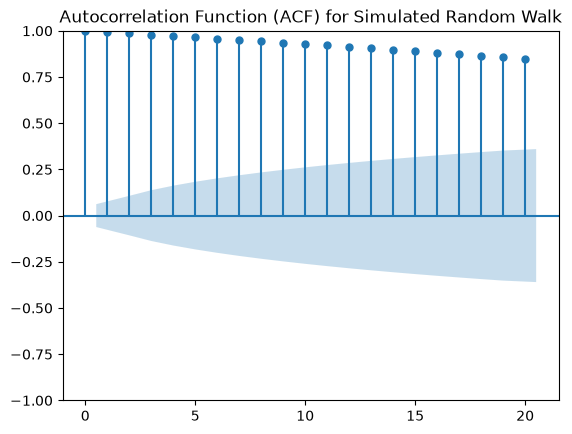

In [22]:
# Plot ACF for the stationary process
plot_acf(random_walk, lags=20, title='Autocorrelation Function (ACF) for Simulated Random Walk')
plt.show()

If the differenced series is a result of a **random walk**, we expect the ACF to show:

- **No significant autocorrelation** beyond lag 0
- A quick drop-off within the confidence bounds

This would indicate that the differenced series is **uncorrelated** and **stationary**, supporting the conclusion that our simulation is a **random walk**.

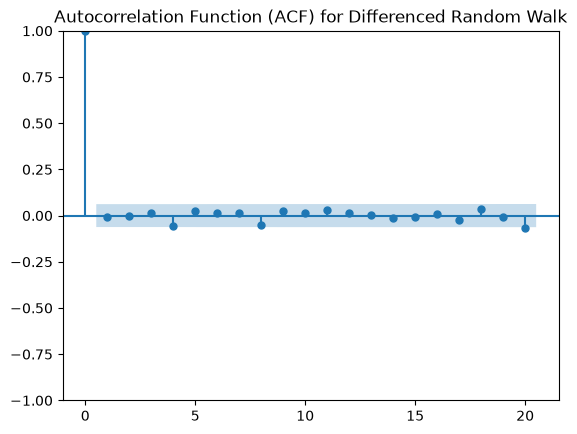

In [23]:
# Plot ACF for the differenced random walk
plot_acf(diff_random_walk, lags=20, title='Autocorrelation Function (ACF) for Differenced Random Walk')
plt.show()

The ACF plots provide visual confirmation of the theoretical behaviour of stationary and non-stationary processes.

- In the **stationary series**, autocorrelation quickly drops off, indicating weak dependence beyond short lags.
- In the **non-stationary series**, autocorrelation remains strong across all 20 lags, reflecting the memory and non-reverting nature of a unit root process.

This confirms what we expect: **non-stationary series are highly persistent, while stationary ones tend to fluctuate around a stable mean**.